In [11]:
import importlib
import eval_functions
importlib.reload(eval_functions)
from eval_functions import *
import pandas as pd
from enum import Enum
import numpy as n

from IPython.display import display
# make tables interactive
from itables import init_notebook_mode
import itables.options as opt
init_notebook_mode(all_interactive=True, connected=True)
opt.maxBytes=0

In [12]:
KOFOLA="kofola-aba11bc"
OLD_KOFOLA="kofola-c716623"
KOFOLA_EARLY="kofola_early-8107e45"
SPOT="spot-2.14.1"
SPOT_FORQ="spot-forq-2.14.1"
FORKLIFT="forklift-forklift"

# Timeout (in seconds) 
TIMEOUT=120


TOOLS = list(dict.fromkeys([ # small hack so that we get list of unique values (i.e. a set, but also in the given order; see https://stackoverflow.com/questions/1653970/does-python-have-an-ordered-set)
    KOFOLA,
    SPOT,
    OLD_KOFOLA,
    SPOT_FORQ,
    KOFOLA_EARLY,
    #FORKLIFT,

    # you can add more tools here directly if needed
]))

BA_TOOLS = list(dict.fromkeys([
    FORKLIFT,

    # you can add more tools here directly if needed
]))

BENCHES = [
  "autohyper",
  "rabit",
  "termination",
  "pecan",
]

In [13]:
df_all = load_benches_incl(BENCHES, TOOLS, TIMEOUT) # last parameter is timeout
df_ba_all = ba_bench_to_hoa(load_benches_incl(BENCHES, BA_TOOLS, TIMEOUT))
df_all = left_join_on_name_benchmark(df_all, df_ba_all)
TOOLS.extend(BA_TOOLS) # add the BA tools to the list of tools


## Evaluation

In [14]:

print(simple_table_incl(df_all, TOOLS, BENCHES, separately=False))
print(simple_table_incl(df_all, TOOLS, BENCHES, separately=True))

# of automata: 1014
----------------------------------------------------------------------------------------------------
tool                    ✅    ❌     time    time-avg    time-med    TO    ERR    MISSING
--------------------  ----  ----  -------  ----------  ----------  ----  -----  ---------
kofola-aba11bc        1012     2   158.78        0.16        0.00     2      0          0
spot-2.14.1            985    29    89.46        0.09        0.00     3     26          0
kofola-c716623        1010     4   354.43        0.35        0.00     4      0          0
spot-forq-2.14.1       960    54  1297.65        1.35        0.00    52      2          0
kofola_early-8107e45  1007     7   409.50        0.41        0.00     7      0          0
forklift-forklift      978    32  1740.47        1.78        0.12    32      0          4
----------------------------------------------------------------------------------------------------


Benchmark autohyper
# of automata: 72
--------------------

In [15]:
TOOL_FOR_COMPARISON = KOFOLA

### Time

/Users/vhavlena/Documents/VeriFIT/Repo/Buchi complementation/ba-compl-eval/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


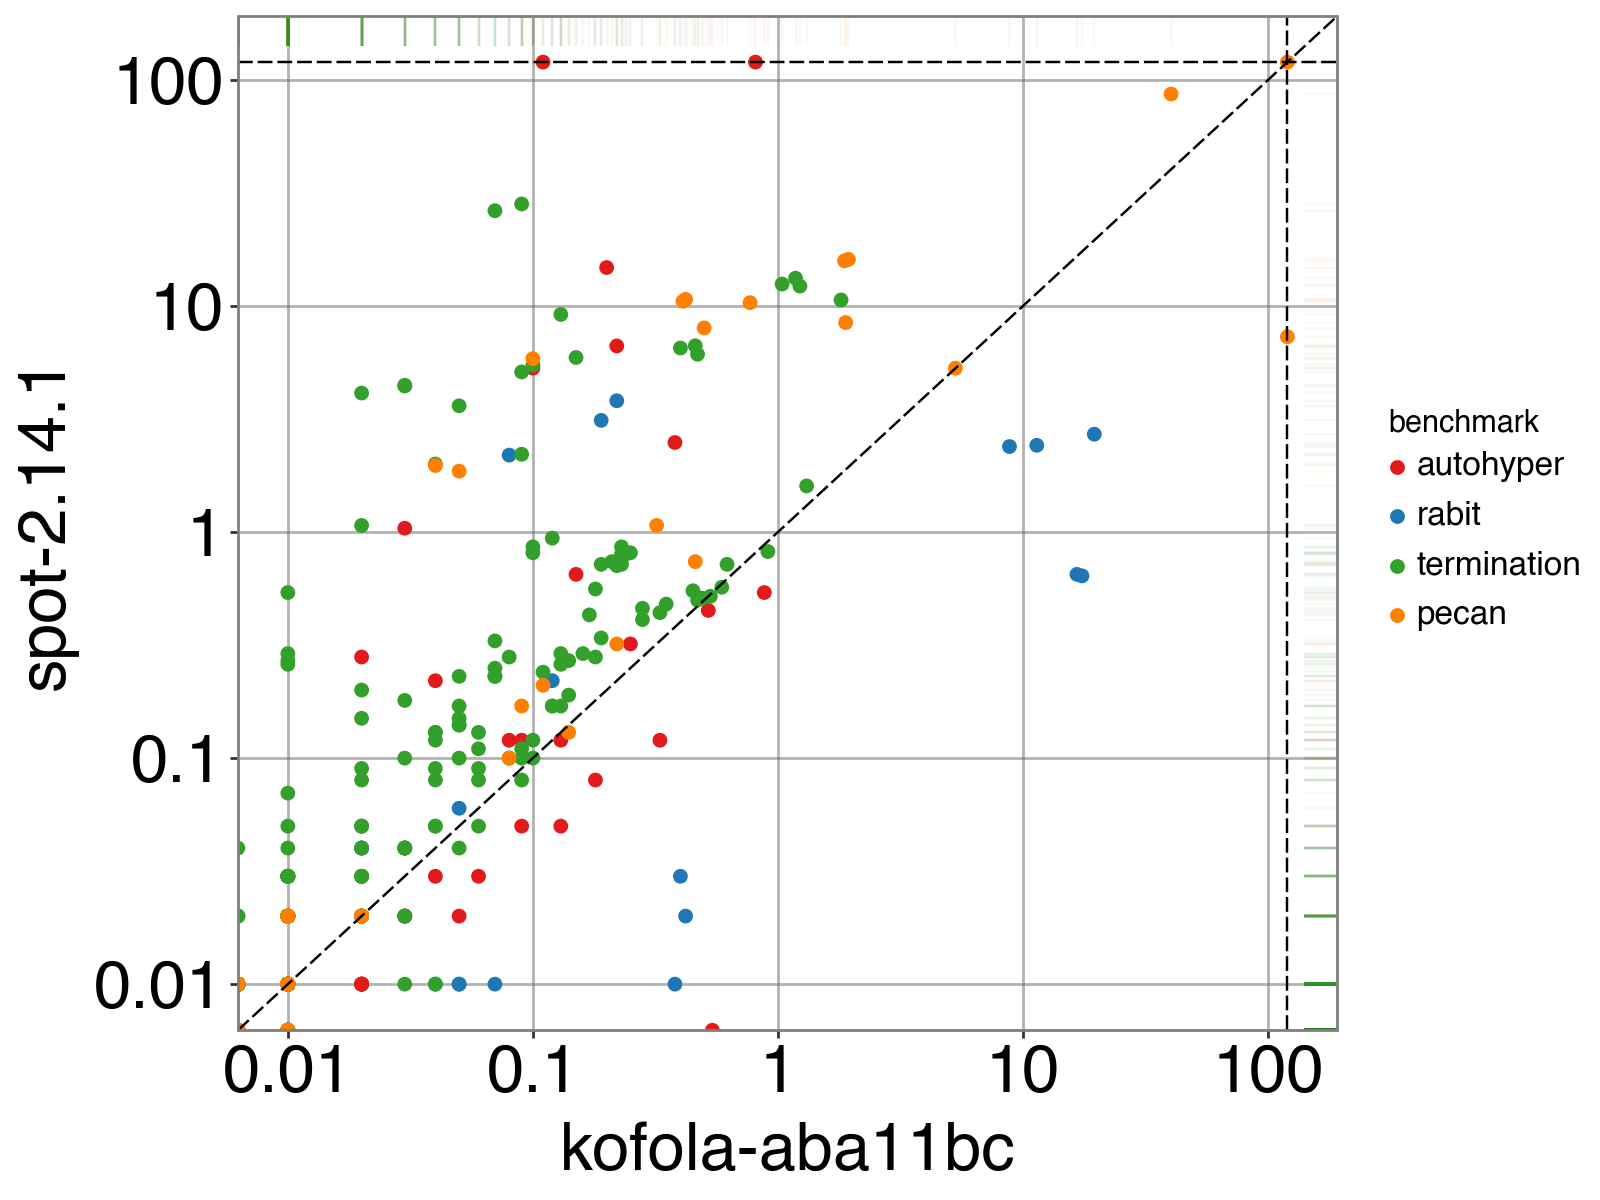

/Users/vhavlena/Documents/VeriFIT/Repo/Buchi complementation/ba-compl-eval/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


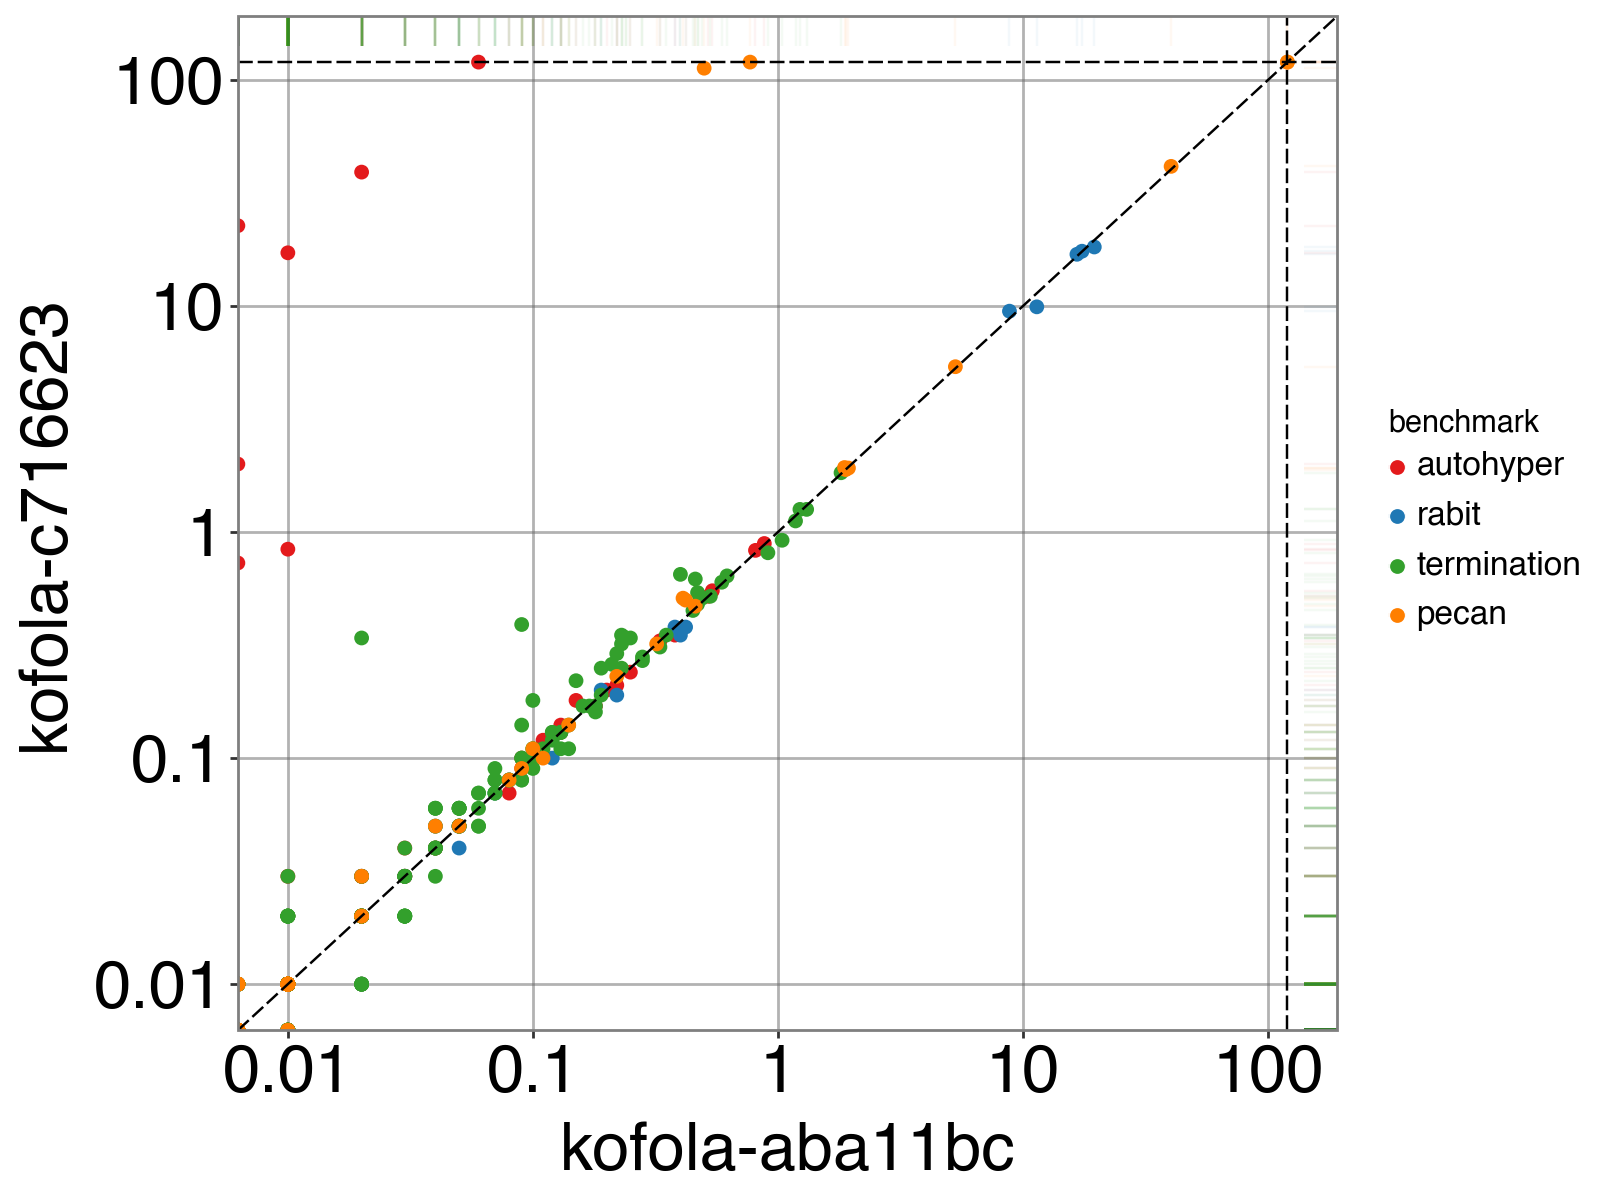

/Users/vhavlena/Documents/VeriFIT/Repo/Buchi complementation/ba-compl-eval/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


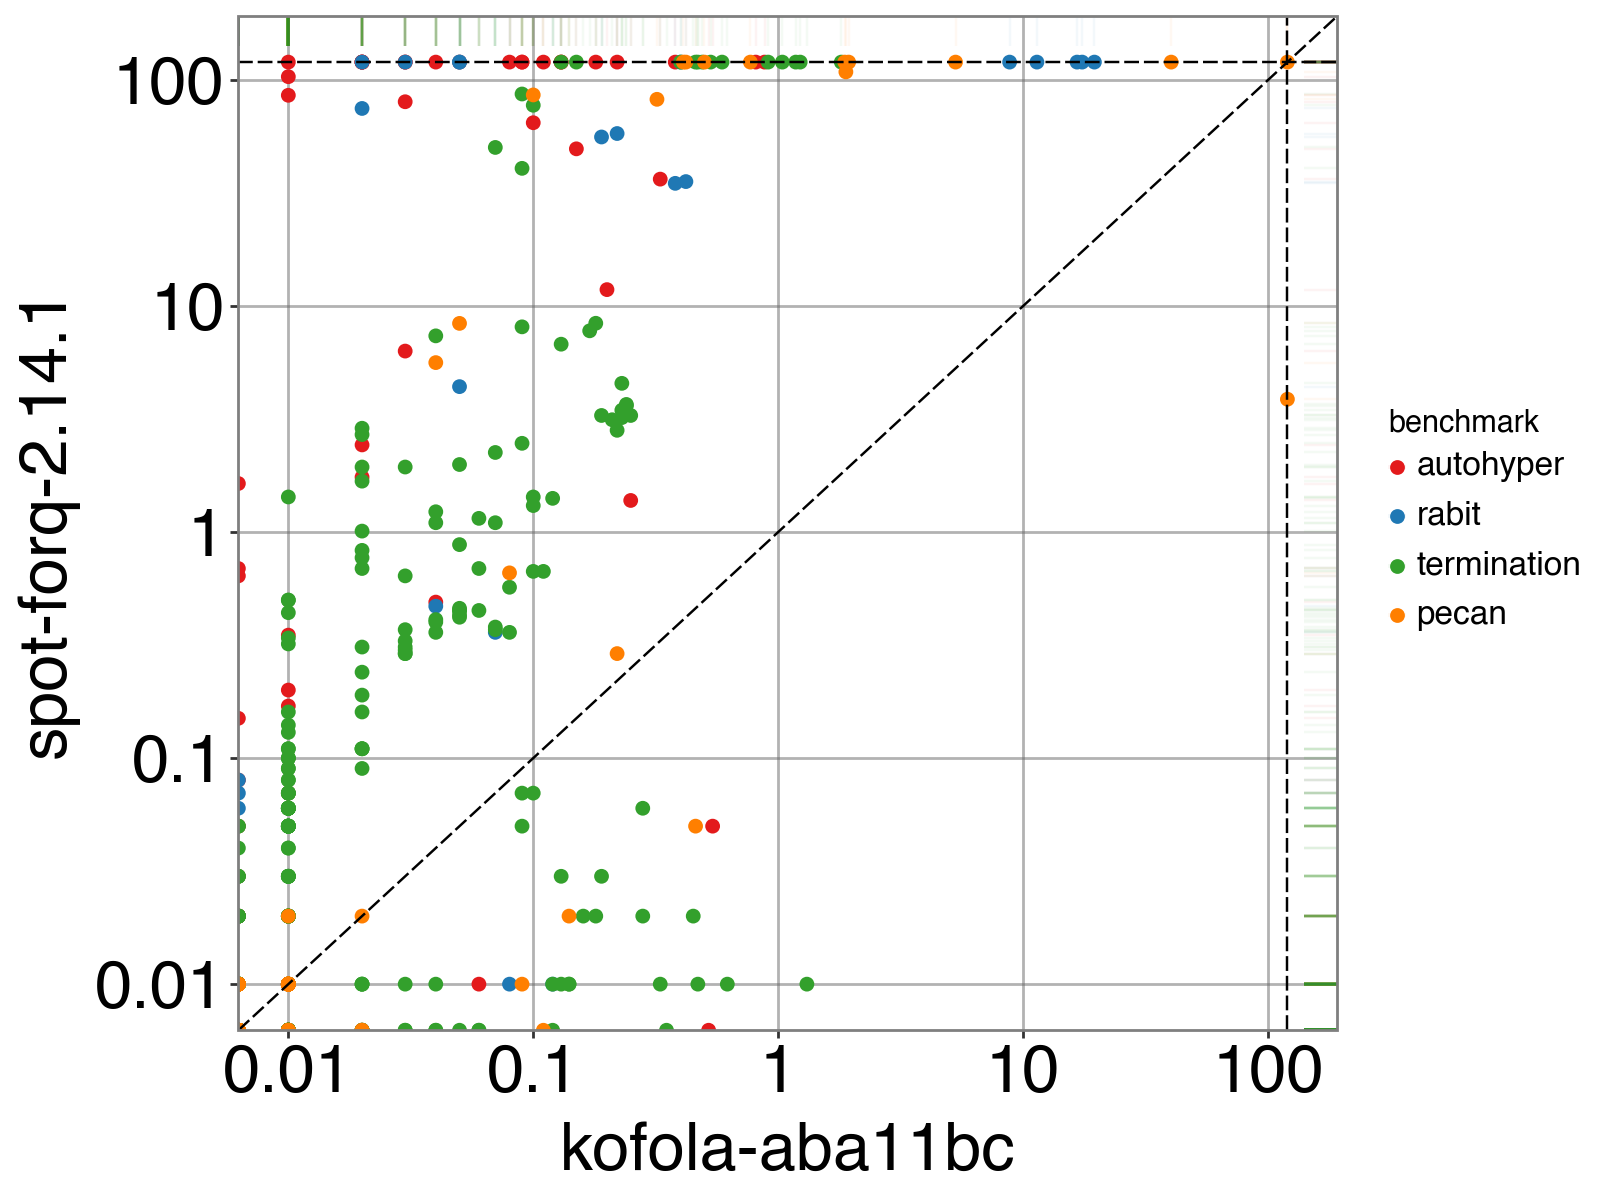

/Users/vhavlena/Documents/VeriFIT/Repo/Buchi complementation/ba-compl-eval/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


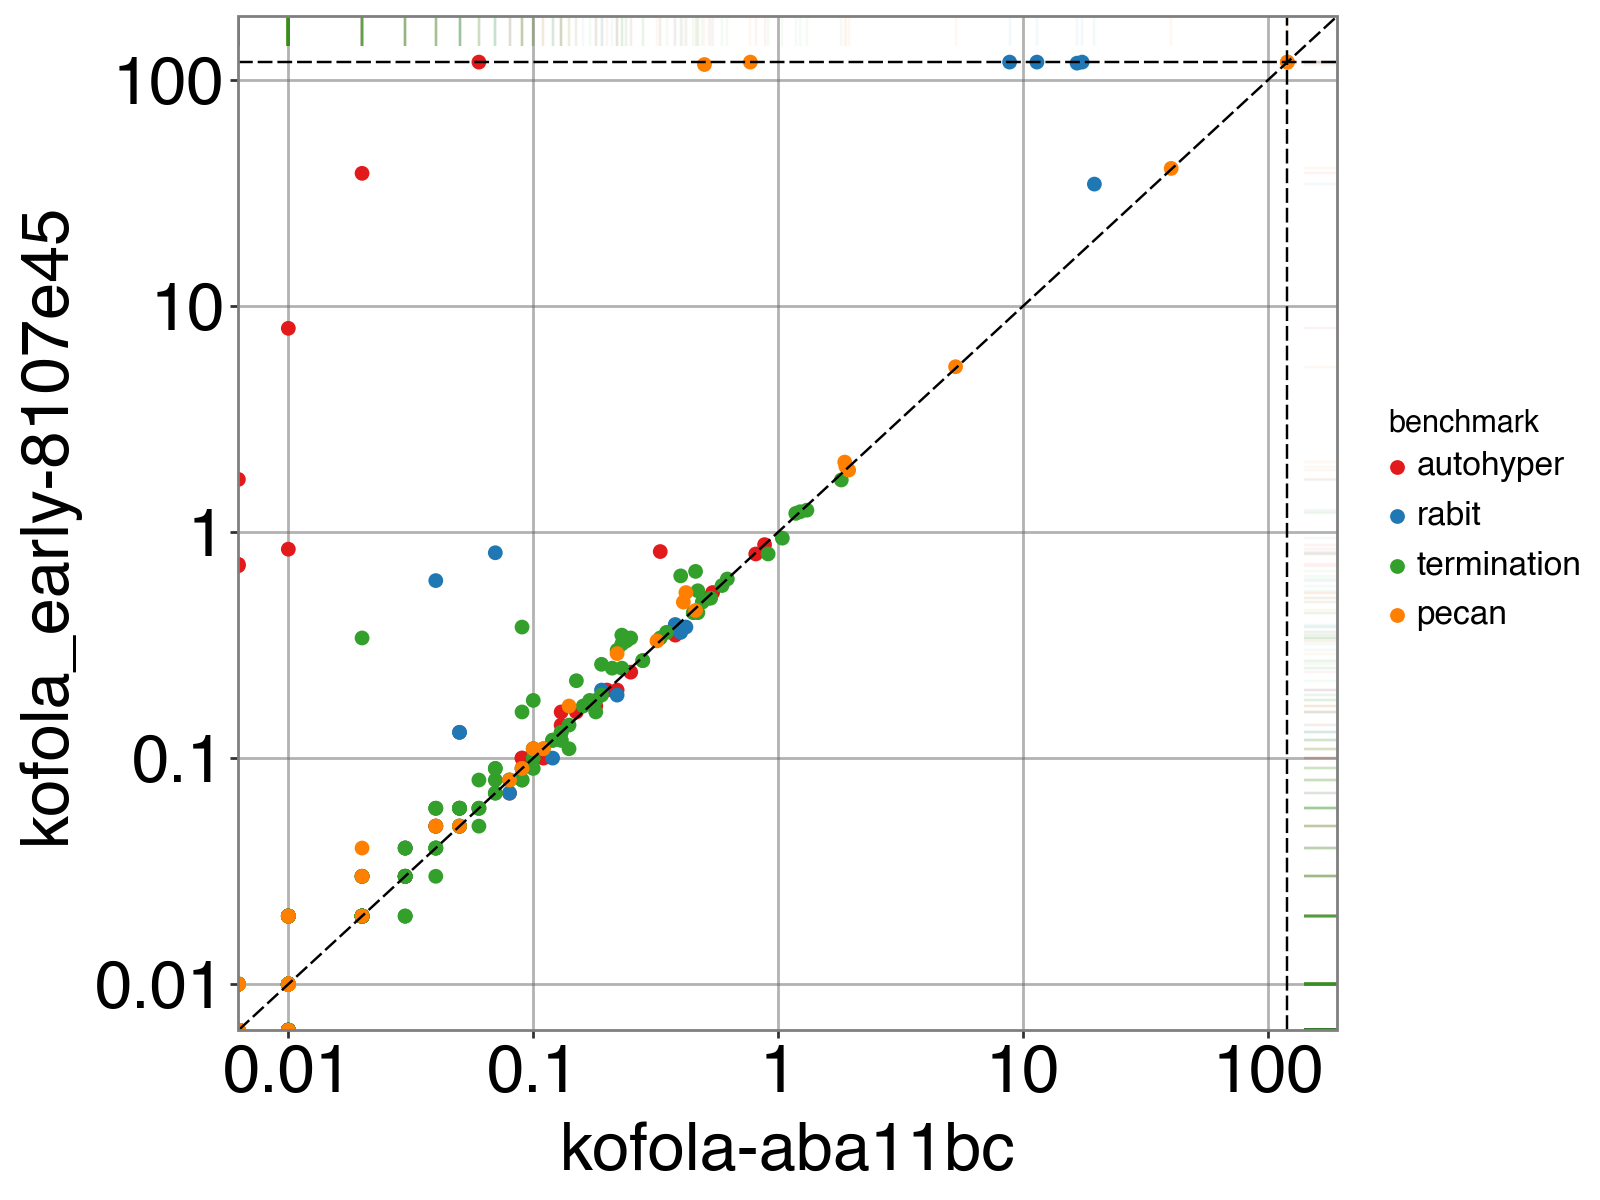

/Users/vhavlena/Documents/VeriFIT/Repo/Buchi complementation/ba-compl-eval/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


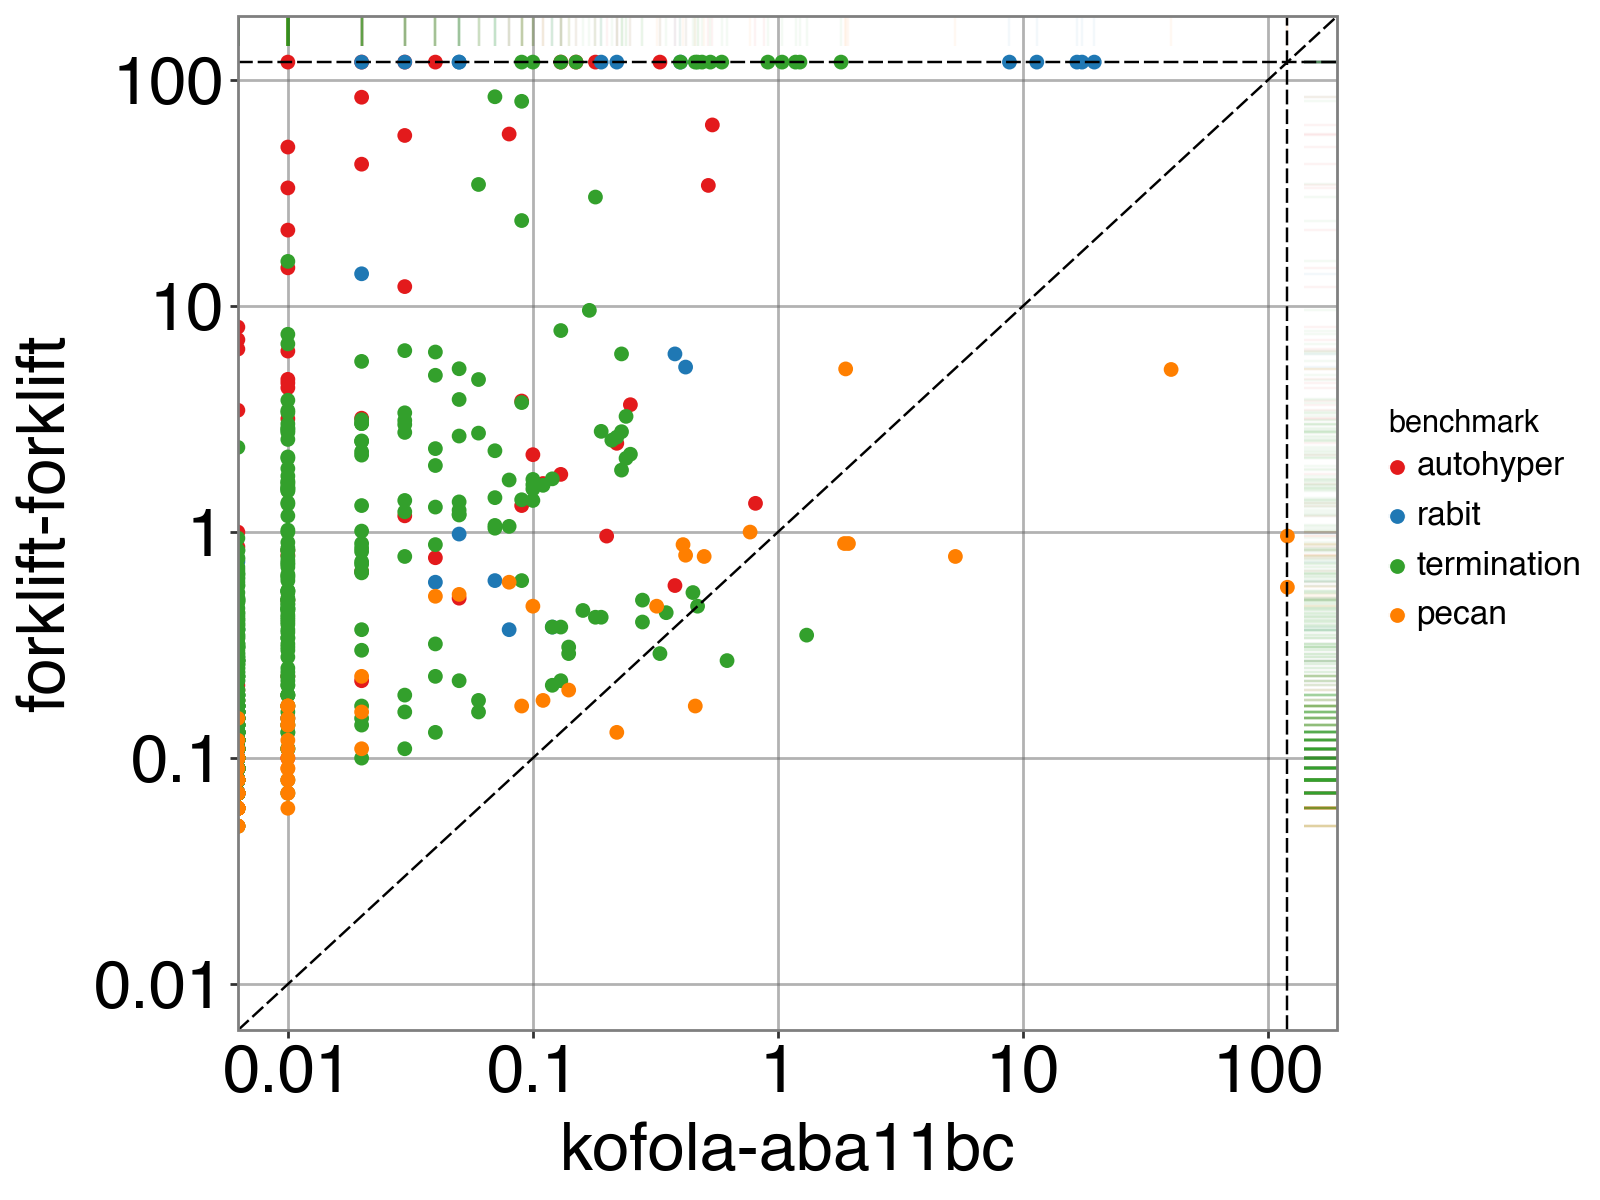

In [16]:
for tool in TOOLS:
    if tool != TOOL_FOR_COMPARISON:
        display(scatter_plot(df_all, TOOL_FOR_COMPARISON, tool, color_column="benchmark", timeout=TIMEOUT, legend_name_map={"advanced_automata_termination":"termination"}))

### More detailed evaluation

In [21]:
sanity_check(df_all, TOOL_FOR_COMPARISON, [tool for tool in TOOLS if tool!=TOOL_FOR_COMPARISON])

Loading ITables v2.4.4 from the internet... (need help?)


In [18]:
get_errors_incl(df_all, TOOL_FOR_COMPARISON)

Loading ITables v2.4.4 from the internet... (need help?)


In [19]:
get_solved_incl(df_all, TOOL_FOR_COMPARISON)

Loading ITables v2.4.4 from the internet... (need help?)


In [20]:
get_timeouts_incl(df_all, TOOL_FOR_COMPARISON)

Loading ITables v2.4.4 from the internet... (need help?)
